In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le fichier CSV
df = pd.read_csv(
    "n0.csv",
    sep=";",           # séparateur entre colonnes
    decimal=",",       # séparateur décimal
    header=None,       # pas d'entêtes
    names=["x", "y"]   # noms de colonnes
)
dft = pd.read_csv(
    "n0t.csv",
    sep=";",           # séparateur entre colonnes
    decimal=",",       # séparateur décimal
    header=None,       # pas d'entêtes
    names=["x", "y"]   # noms de colonnes
)
dftt = pd.read_csv(
    "ntt.csv",
    sep=";",           # séparateur entre colonnes
    decimal=",",       # séparateur décimal
    header=None,       # pas d'entêtes
    names=["x", "y"]   # noms de colonnes
)

print(df.head())  # Vérifier que la lecture est correcte

# Tracer les points
plt.plot(df["x"], df["y"], "-", label="courbe extraite")
plt.plot(dft["x"], dft["y"], "--", label="courbe extraite")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'ntt.csv'

In [4]:
import pandas as pd

# si c'est séparé par des espaces
df = pd.read_csv("data/GHD_bord_article_distribution_24-04-2024.table", delim_whitespace=True)

# si c'est séparé par des tabulations
# df = pd.read_csv("fichier.table", sep="\t")

print(df.head())


      #Curve       0,   200  points
0         #x        y  type     NaN
1  -20.57143  0.00000     i     NaN
2  -20.36557  0.00023     i     NaN
3  -20.15954  0.00048     i     NaN
4  -19.95340  0.00075     i     NaN


/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_33440/3077412420.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("data/GHD_bord_article_distribution_24-04-2024.table", delim_whitespace=True)


In [6]:
import os

def save_table(x, y, name):
    """
    Sauvegarde deux listes x et y dans un fichier .table
    au format spécifié.
    
    Args:
        x (list or array): valeurs en abscisse
        y (list or array): valeurs en ordonnée
        name (str): nom du fichier (sans extension)
    """
    # Créer le dossier ./data s'il n'existe pas
    os.makedirs("./data", exist_ok=True)

    # Nombre de points
    N = len(x)
    if len(y) != N:
        raise ValueError("x et y doivent avoir la même longueur.")

    # Nom complet du fichier
    filepath = f"./data/{name}.table"

    with open(filepath, "w") as f:
        # Écrire l'entête
        f.write(f"#Curve       0,   {N}  points\n")
        f.write("0         #x        y  type     NaN\n")
        
        # Écrire les données
        for i, (xi, yi) in enumerate(zip(x, y), start=1):
            f.write(f"{i:<5d} {xi:10.5f} {yi:10.5f}     i     NaN\n")
    
    print(f"Fichier sauvegardé dans {filepath}")



Fichier sauvegardé dans ./data/n0.table
--- Fit poly4 ---
params: [ 2.73119424e+02  1.06519424e+01 -6.99579173e+03  7.24438188e+01
  3.45419397e+04]
errors: [   7.98407581   70.83586094  403.00823588  625.00141421 2751.00693791]
--- Fit tf ---
params: [  397.85254605 39248.26859819]
errors: [  1.33362322 305.25050916]
--- Fit power_quad ---
params: [397.93813992  86.45503556   0.73017657   8.62090423]
errors: [7.37703355 3.55610626 0.02998771 7.09475958]
--- Fit phys ---
params: [0. 0. 0. 0. 1.]
errors: [inf inf inf inf inf]
--- Fit lamb ---
params: [2.22108256]
errors: [0.01379968]


/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_33440/2019587949.py:101: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_phys, pcov_phys = curve_fit(phys_model, x, y, p0=p0, maxfev=50000)


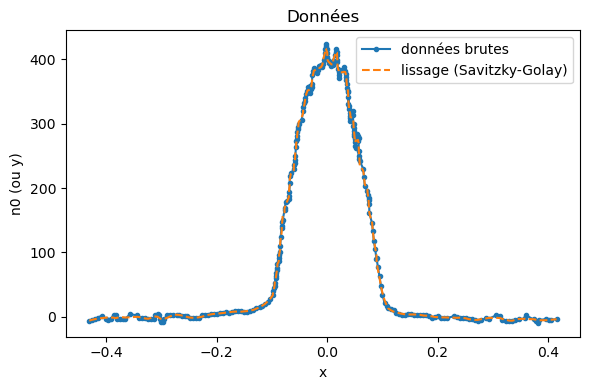

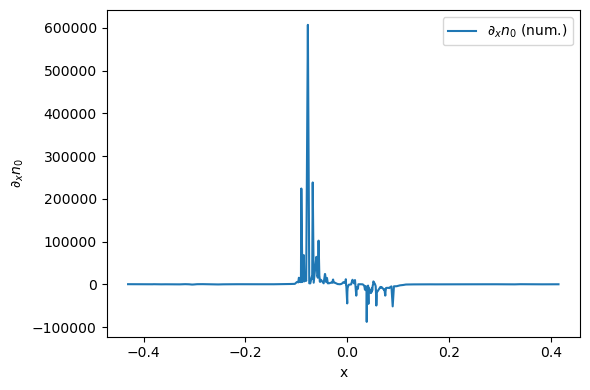

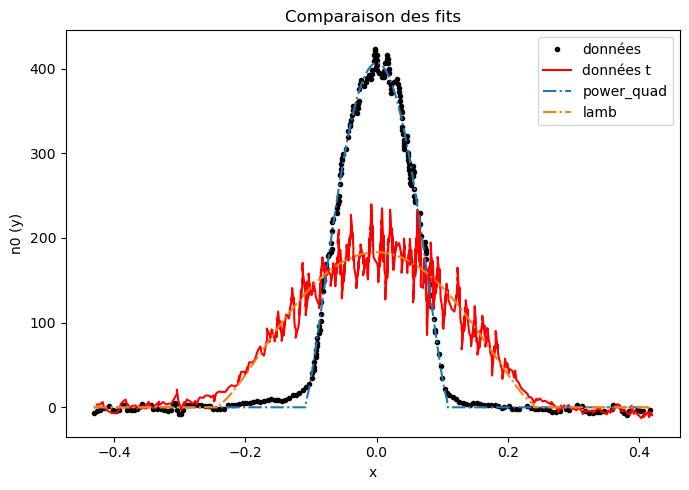

In [8]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

# --- 1) charger les données (format détecté d'après ton exemple) ---
df = pd.read_csv("n0.csv", sep=";", decimal=",", header=None, names=["x","y"])
x = df["x"].values
y = df["y"].values
dft = pd.read_csv("nt.csv", sep=";", decimal=",", header=None, names=["x","y"])
xt = dft["x"].values
yt = dft["y"].values

# trier par x au cas où
order = np.argsort(x)
x = x[order]
y = y[order]

# --- 2) dérivée numérique (avec smoothing optionnel) ---
# smoothing faible optionnel pour réduire le bruit avant dérivation
y_smooth = savgol_filter(y, window_length=11 if len(y)>11 else 5, polyorder=2, mode='interp')
dy_dx = np.gradient(y_smooth, x)

# afficher un diagnostic
plt.figure(figsize=(6,4))
plt.plot(x, y, ".-", label="données brutes")
plt.plot(x, y_smooth, "--", label="lissage (Savitzky-Golay)")
plt.xlabel("x"); plt.ylabel("n0 (ou y)"); plt.legend(); plt.title("Données")
plt.tight_layout()

plt.figure(figsize=(6,4))
plt.plot(x, dy_dx, "-", label=r"$\partial_x n_0$ (num.)")
plt.xlabel("x"); plt.ylabel(r"$\partial_x n_0$"); plt.legend(); plt.tight_layout()


# -------------------------
# --- 3) modèles pour fit
# -------------------------
# Modèle A : polynôme de degré d
def poly_model(x, *coeffs):
    # coeffs: a0 + a1 x + a2 x^2 + ...
    return sum(c * x**i for i, c in enumerate(coeffs))

# Modèle B : Thomas-Fermi (paraboloïde): n(x) = max(A - B x^2, 0)
def tf_parabola(x, A, B):
    return np.maximum(A - B * x**2, 0.0)

# Modèle C : terme puissance + quadratique, forme générique
# n(x) = a*(1 - b*x^2)^(1/alpha) + c  (modèle plus souple)
def power_quad_model(x, a, b, alpha, c):
    arg = 1 - b * x**2
    # protéger les valeurs négatives (retourne 0 quand arg <=0)
    out = np.zeros_like(x)
    mask = arg > 0
    out[mask] = a * (arg[mask])**(1.0/alpha) + c
    return out

# Modèle D : modèle linéaire combinaison (ex: mu_p - b - 1/2 m w^2 x^2 / lambda^(2/alpha))
# Proposition : n(x) = a*(mu_p - b - 0.5*m*w2 * x^2 / lambda**(2/alpha))
def phys_model(x, a, mu_p_minus_b, m_w2_over2, lam, alpha):
    # m_w2_over2 corresponds to (1/2 m omega^2)_|| in your sketch
    # lam and alpha included; we allow lam>0 and alpha>0
    #denom = lam**(2.0/alpha)
    y = np.power(a * (mu_p_minus_b - m_w2_over2 * x**2), 1/alpha)
    return np.where(y>=0 , y ,0 )

# -------------------------
# --- 4) exécuter quelques fits (exemples) ---
# -------------------------
fits = {}

# 4.1 polynôme degré 4 (robuste si pas d'extrapolation)
deg = 4
p0 = np.zeros(deg+1)
coeffs_poly, cov_poly = curve_fit(lambda x, *c: poly_model(x, *c), x, y, p0=p0, maxfev=30000)
fits['poly4'] = (coeffs_poly, cov_poly)
#print(fits['poly4'])

# 4.2 TF parabola (initial guesses)
p0 = [np.max(y), 1.0]
try:
    popt_tf, pcov_tf = curve_fit(tf_parabola, x, y, p0=p0, maxfev=30000)
    fits['tf'] = (popt_tf, pcov_tf)
except Exception as e:
    print("tf_parabola fit failed:", e)

# 4.3 modèle puissance+quadratique (p0 prudents)
p0 = [np.max(y), 1e-1, 1.0, 0.0]
bounds = ([0, 0, 0.1, -np.inf], [np.inf, np.inf, 10, np.inf])
try:
    popt_pow, pcov_pow = curve_fit(power_quad_model, x, y, p0=p0, bounds=bounds, maxfev=50000)
    fits['power_quad'] = (popt_pow, pcov_pow)
except Exception as e:
    print("power_quad fit failed:", e)

# 4.4 modèle physique (ex: phys_model)
p0 = [0, 0, 0.0, .0, 1]  # a, mu_p_minus_b, m_w2_over2, lam, alpha
try:
    popt_phys, pcov_phys = curve_fit(phys_model, x, y, p0=p0, maxfev=50000)
    fits['phys'] = (popt_phys, pcov_phys)
except Exception as e:
    print("phys_model fit failed:", e)

def n_model(x, lamb):
    return power_quad_model(x/lamb, *fits['power_quad'][0])/lamb

try:
    popt_lamb, pcov_lamb = curve_fit(n_model, xt, yt, p0=[1], maxfev=30000)
    fits['lamb'] = (popt_lamb, pcov_lamb)
except Exception as e:
    print("lamb fit failed:", e)
   


# -------------------------
# --- 5) afficher résultats et comparer
# -------------------------
plt.figure(figsize=(7,5))
plt.plot(x, y, 'k.', label='données')
save_table(x*1000, y, "n0")
plt.plot(xt, yt, 'r-', label='données t')
xfine = np.linspace(np.min(x), np.max(x), 1000)

# polynôme
yp = poly_model(xfine, *coeffs_poly)
#plt.plot(xfine, yp, label=f'poly deg {deg}')

# TF si ok
if 'tf' in fits:
    popt_tf = fits['tf'][0]
    #plt.plot(xfine, tf_parabola(xfine, *popt_tf), '--', label='TF parabola')

if 'power_quad' in fits:
    popt_pow = fits['power_quad'][0]
    plt.plot(xfine, power_quad_model(xfine, *popt_pow), '-.', label='power_quad')

if 'phys' in fits:
    popt_phys = fits['phys'][0]
    #plt.plot(xfine, phys_model(xfine, *popt_phys), ':', label='phys_model')
    #print( phys_model(xfine, *popt_phys))

if 'lamb' in fits:
    popt_pow = fits['lamb'][0]
    plt.plot(xfine, n_model(xfine, *popt_pow), '-.', label='lamb')

plt.legend(); plt.xlabel('x'); plt.ylabel('n0 (y)'); plt.title('Comparaison des fits'); plt.tight_layout()

# imprimer paramètres
for k, v in fits.items():
    params, cov = v
    print(f"--- Fit {k} ---")
    print("params:", params)
    try:
        perr = np.sqrt(np.diag(cov))
        print("errors:", perr)
    except Exception:
        pass

# sauvegarder résultats si besoin
pd.DataFrame({'x': xfine, 'poly4': yp}).to_csv("fit_poly4_xfine.csv", index=False)


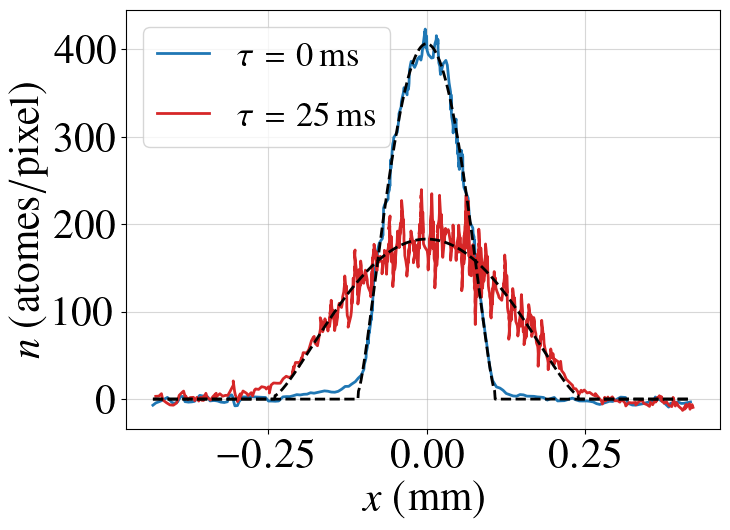

In [10]:
import matplotlib.pyplot as plt
import numpy as np


# Tracé
plt.figure(figsize=(8,6))
# --- Paramètres globaux ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}", 
    "font.size": 30                     # taille de police globale
})

# Données (lignes continues)
plt.plot(x, y, color="#1F77B4",linewidth=2, label=r"$\tau = 0\,\mathrm{ms}$")
plt.plot(xt, yt, color="#D62728",linewidth=2, label=r"$\tau = 25\,\mathrm{ms}$")

# Fits (pointillés)
plt.plot(xfine, power_quad_model(xfine, *fits['power_quad'][0]), "--",linewidth=2, color="black")#, label=r"Fit $\tau = 0\,\mathrm{ms}$")
plt.plot(xfine, n_model(xfine, *popt_pow), "--",linewidth=2, color="black")#, label=r"Fit $\tau = 25\,\mathrm{ms}$")

# Axes
plt.xlabel(r"$x \,(\mathrm{mm})$")
plt.ylabel(r"$n \,(\mathrm{atomes/pixel})$")

# Légende et mise en forme
# Légende
plt.legend(
    loc="upper left",     # position : 'upper right', 'lower left', etc.
    fontsize=25,           # taille du texte
    #frameon=False,         # pas de boîte autour
    handlelength=1.5,        # longueur du trait dans la légende
    labelspacing=0.8       # espacement vertical entre entrées
)

plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig("fit_n_vs_tau.pdf", dpi=300, bbox_inches="tight")  # PDF pour article
plt.show()


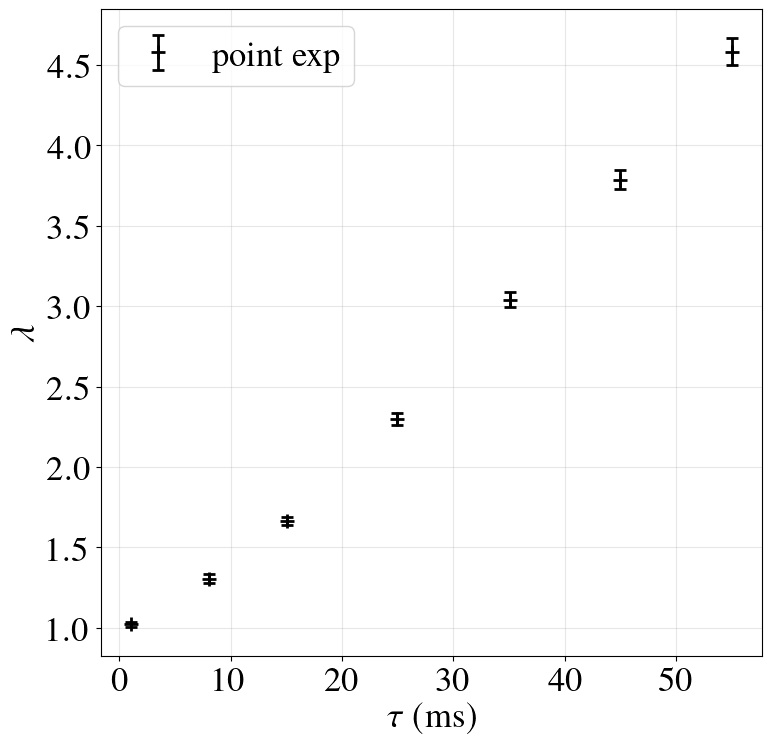

In [12]:
tau = [1.05834885164494,8.02268495005925,15.061367868630438,24.973618870266915,35.11102646577507,44.945403758252915,55.006066249083005]
lamb = [1.022346368715084,1.305400372439479,1.6629422718808193, 2.2960893854748607,3.040968342644321,3.7858472998137804,4.582867783985103]
errer = [(1.0372439478584727-1.0074487895716953)/2, 
         (1.3351955307262573-1.2756052141527006)/2,
         (1.6927374301675986-1.6405959031657362)/2,
         (2.333333333333334-2.258845437616388)/2,
         (3.0782122905027935-2.9813780260707636)/2,
         (3.845437616387337-3.7262569832402237)/2,
         (4.664804469273744-4.500931098696462)/2]

import matplotlib.pyplot as plt

# Tes données
tau = [1.05834885164494, 8.02268495005925, 15.061367868630438,
       24.973618870266915, 35.11102646577507, 44.945403758252915, 55.006066249083005]

lamb = [1.022346368715084, 1.305400372439479, 1.6629422718808193,
        2.2960893854748607, 3.040968342644321, 3.7858472998137804, 4.582867783985103]

errer = [
    (1.0372439478584727 - 1.0074487895716953) / 2,
    (1.3351955307262573 - 1.2756052141527006) / 2,
    (1.6927374301675986 - 1.6405959031657362) / 2,
    (2.333333333333334 - 2.258845437616388) / 2,
    (3.0782122905027935 - 2.9813780260707636) / 2,
    (3.845437616387337 - 3.7262569832402237) / 2,
    (4.664804469273744 - 4.500931098696462) / 2
]

df = pd.read_csv("TF3D.csv", sep=";", decimal=",", header=None, names=["x","y"])
x = df["x"].values
y = df["y"].values

# Style LaTeX si tu veux cohérent avec newtx
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
    "font.size": 25
})

plt.figure(figsize=(8,8))

# Tracé avec barres d’erreurs
plt.errorbar(
    tau, lamb, yerr=errer,
    fmt="k+",                # 'k' noir, '+' marqueur
    markeredgewidth=2,
    markersize=10,           # taille du +
    elinewidth=2,            # épaisseur des barres
    capsize=4,               # petits "chapeaux" en haut et bas
    capthick=2,
    label = "point exp"
)

# Axes
plt.xlabel(r"$\tau \, (\mathrm{ms})$")
plt.ylabel(r"$\lambda$")

plt.legend(
    loc="upper left",     # position : 'upper right', 'lower left', etc.
    fontsize=25,           # taille du texte
    #frameon=False,         # pas de boîte autour
    handlelength=1.5,        # longueur du trait dans la légende
    labelspacing=0.8       # espacement vertical entre entrées
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

dotλ0 = -0.03166299493260146
ω∥ = 0.049684308286744305
λ0 = 1.161303713154483


/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_33440/3066454650.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(dotl0**2 + (2*omega**2/alpha) * (lmbda0**(-alpha) - lmbda**(-alpha)))


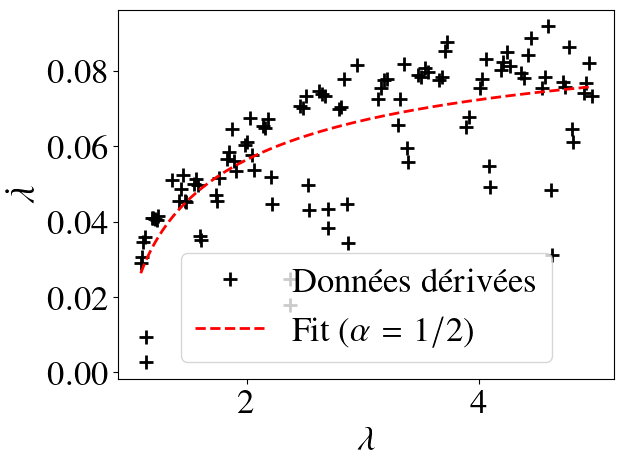

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# === Fonction modèle ===
def model(lmbda, dotl0, omega, lmbda0):
    alpha = 0.5  # fixé
    return np.sqrt(dotl0**2 + (2*omega**2/alpha) * (lmbda0**(-alpha) - lmbda**(-alpha)))

# === Charger données ===
# Fichier avec deux colonnes : tau, lambda
df = pd.read_csv("TF3D.csv", sep=";", decimal=",", header=None, names=["x","y"])
tau = df["x"].values
lambda_exp = df["y"].values

# === Calcul de dot(lambda) par différences finies ===
dotlambda_exp = np.gradient(lambda_exp, tau)  # dérivée numérique

# === Ajustement ===
p0 = [0.1, 1.0, lambda_exp[0]]  # valeurs initiales : dotl0, omega, lambda0
params, cov = curve_fit(model, lambda_exp, dotlambda_exp, p0=p0)

dotl0_fit, omega_fit, lmbda0_fit = params
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)

# === Tracé ===
lmbda_fit = np.linspace(min(lambda_exp), max(lambda_exp), 500)
dotlambda_fit = model(lmbda_fit, *params)

plt.plot(lambda_exp, dotlambda_exp, "k+", markersize=10, markeredgewidth=2, label="Données dérivées")
plt.plot(lmbda_fit, dotlambda_fit, "r--", linewidth=2, label="Fit ($\\alpha=1/2$)")

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\dot{\lambda}$")
plt.legend()
plt.show()


dotλ0 = -0.03209100796007907
ω∥ = -0.05733538593448522
λ0 = 1.0840645378464995


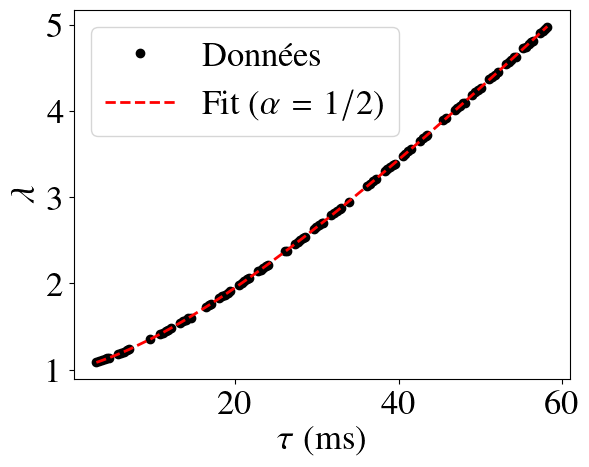

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# === ODE ===
def ode3D(t, lmbda, dotl0, omega, lmbda0):
    alpha = 0.5
    return np.sqrt(dotl0**2 + (2*omega**2/alpha)*(lmbda0**(-alpha) - lmbda[0]**(-alpha)))

# === Solution numérique pour un jeu de paramètres ===
def solve_lambda3D(tau, dotl0, omega, lmbda0):
    sol = solve_ivp(
        lambda t, y: ode3D(t, y, dotl0, omega, lmbda0),
        [tau[0], tau[-1]], [lmbda0],
        t_eval=tau, rtol=1e-8, atol=1e-8
    )
    return sol.y[0]

# === Fonction modèle pour curve_fit ===
def model3D(tau, dotl0, omega, lmbda0):
    return solve_lambda3D(tau, dotl0, omega, lmbda0)

# === Charger données ===
df = pd.read_csv("TF3D.csv", sep=";", decimal=",", header=None, names=["x","y"])
tauN = df["x"].values
lambda_exp = df["y"].values

# === Ajustement ===
p0 = [0.1, 1.0, lambda_exp[0]]  # dotλ0, ω, λ0
params3D, cov = curve_fit(model3D, tauN, lambda_exp, p0=p0)

dotl0_fit, omega_fit, lmbda0_fit = params3D
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)

# === Tracé ===
lambda_fit = model3D(tauN, *params3D)

plt.plot(tauN, lambda_exp, "ko", label="Données")
plt.plot(tauN, model3D(tauN, *params3D), "r--", linewidth=2, label="Fit ($\\alpha=1/2$)")

plt.xlabel(r"$\tau$ (ms)")
plt.ylabel(r"$\lambda$")
plt.legend()
plt.show()


dotλ0 = -0.022740277042795624
ω∥ = -0.05733538644275247
λ0 = 1.0011285278785853


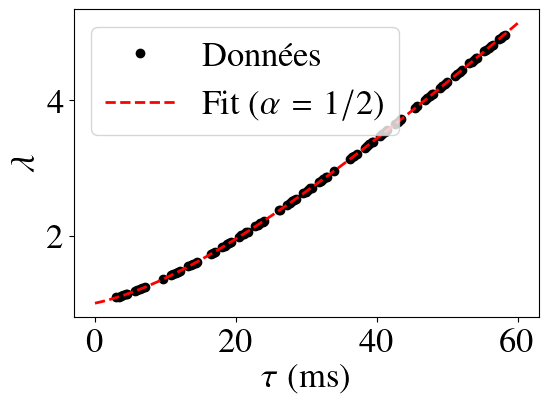

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# === ODE ===
def ode3D(t, lmbda, dotl0, omega, lmbda0):
    alpha = 0.5
    return np.sqrt(dotl0**2 + (2*omega**2/alpha)*(lmbda0**(-alpha) - lmbda[0]**(-alpha)))

# === Solution numérique pour un jeu de paramètres ===
def solve_lambda3D(tau, dotl0, omega, lmbda0):
    sol = solve_ivp(
        lambda t, y: ode3D(t, y, dotl0, omega, lmbda0),
        [0, tau[-1]],      # Commencer à tau = 0
        [lmbda0],          # λ(tau=0) = λ0
        t_eval=tau, rtol=1e-8, atol=1e-8
    )
    return sol.y[0]

# === Fonction modèle pour curve_fit ===
def model3D(tau, dotl0, omega, lmbda0):
    return solve_lambda3D(tau, dotl0, omega, lmbda0)

# === Charger données ===
df = pd.read_csv("TF3D.csv", sep=";", decimal=",", header=None, names=["x","y"])
tau_exp = df["x"].values
lambda_exp = df["y"].values

# === Ajustement ===
p0 = [0.1, 1.0, lambda_exp[0]]  # dotλ0, ω, λ0
params3D, cov = curve_fit(model3D, tau_exp, lambda_exp, p0=p0)

dotl0_fit, omega_fit, lmbda0_fit = params3D
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)

# === Tracé ===
tau_fit = np.linspace(0, 60, 500)  # dense, commence à 0
lambda_fit = model3D(tau_fit, *params3D)

plt.figure(figsize=(6,4))
plt.plot(tau_exp, lambda_exp, "ko", label="Données")
plt.plot(tau_fit, lambda_fit, "r--", linewidth=2, label="Fit ($\\alpha=1/2$)")
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel(r"$\lambda$")
plt.legend()
plt.show()


dotλ0 = -0.05868223613794913
ω∥ = 0.053991524621829115
λ0 = 1.7087946399456264


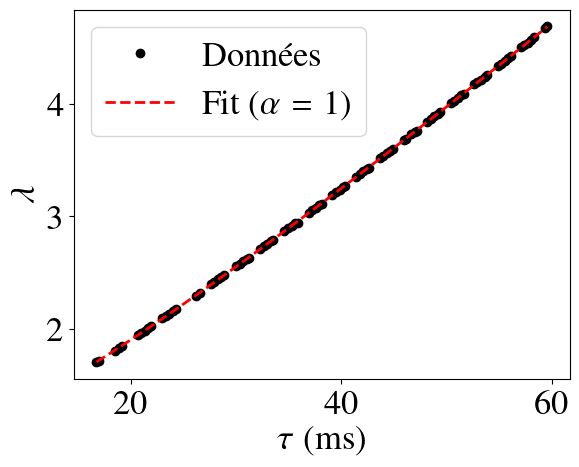

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# === ODE ===
def ode1D(t, lmbda, dotl0, omega, lmbda0):
    alpha = 1
    return np.sqrt(dotl0**2 + (2*omega**2/alpha)*(lmbda0**(-alpha) - lmbda[0]**(-alpha)))

# === Solution numérique pour un jeu de paramètres ===
def solve_lambda1D(tau, dotl0, omega, lmbda0):
    sol = solve_ivp(
        lambda t, y: ode1D(t, y, dotl0, omega, lmbda0),
        [tau[0], tau[-1]], [lmbda0],
        t_eval=tau, rtol=1e-8, atol=1e-8
    )
    return sol.y[0]

# === Fonction modèle pour curve_fit ===
def model1D(tau, dotl0, omega, lmbda0):
    return solve_lambda1D(tau, dotl0, omega, lmbda0)

# === Charger données ===
df = pd.read_csv("TF1D.csv", sep=";", decimal=",", header=None, names=["x","y"])
tauN2 = df["x"].values
lambd= df["y"].values

# === Ajustement ===
p0 = [0.1, 1.0, lambda_exp[0]]  # dotλ0, ω, λ0
params1D, cov = curve_fit(model1D, tauN2, lambd, p0=p0)

dotl0_fit, omega_fit, lmbda0_fit = params1D
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)

# === Tracé ===
lambda_fit = model1D(tauN2, *params1D)

plt.plot(tauN2, lambd, "ko", label="Données")
plt.plot(tauN2, lambda_fit, "r--", linewidth=2, label="Fit ($\\alpha=1$)")

plt.xlabel(r"$\tau$ (ms)")
plt.ylabel(r"$\lambda$")
plt.legend()
plt.show()


dotλ0 = 0.02622336967714916
ω∥ = -0.05399155210440226
λ0 = 0.9452597309059099


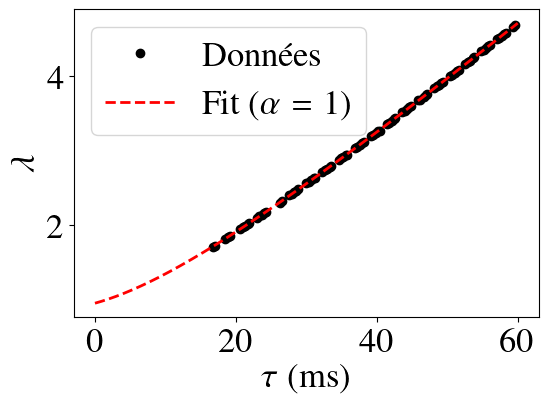

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# === ODE ===
def ode1D(t, lmbda, dotl0, omega, lmbda0):
    alpha = 1
    return np.sqrt(dotl0**2 + (2*omega**2/alpha)*(lmbda0**(-alpha) - lmbda[0]**(-alpha)))

# === Solution numérique pour un jeu de paramètres ===
def solve_lambda1D(tau, dotl0, omega, lmbda0):
    sol = solve_ivp(
        lambda t, y: ode1D(t, y, dotl0, omega, lmbda0),
        [0, tau[-1]],       # commence à tau=0
        [lmbda0],           # lambda(tau=0) = lambda0
        t_eval=tau, rtol=1e-8, atol=1e-8
    )
    return sol.y[0]

# === Fonction modèle pour curve_fit ===
def model1D(tau, dotl0, omega, lmbda0):
    return solve_lambda1D(tau, dotl0, omega, lmbda0)

# === Charger données ===
df = pd.read_csv("TF1D.csv", sep=";", decimal=",", header=None, names=["x","y"])
tau_exp = df["x"].values
lambda_exp = df["y"].values

# === Ajustement ===
p0 = [0.1, 1.0, lambda_exp[0]]  # dotλ0, ω, λ0
params1D, cov = curve_fit(model1D, tau_exp, lambda_exp, p0=p0)

dotl0_fit, omega_fit, lmbda0_fit = params1D
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)

# === Tracé ===
#tau_fit = np.linspace(0, tau_exp[-1], 500)  # vecteur dense pour tracé
lambda_fit = model1D(tau_fit, *params1D)

plt.figure(figsize=(6,4))
plt.plot(tau_exp, lambda_exp, "ko", label="Données")
plt.plot(tau_fit, lambda_fit, "r--", linewidth=2, label="Fit ($\\alpha=1$)")
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel(r"$\lambda$")
plt.legend()
plt.show()


dotλ0 = 0.03390664326686554
ω∥ = -0.0542803458028699
λ0 = 1.0226584172689785
α = -2.223756613194512
γ = 0.02330268424883378


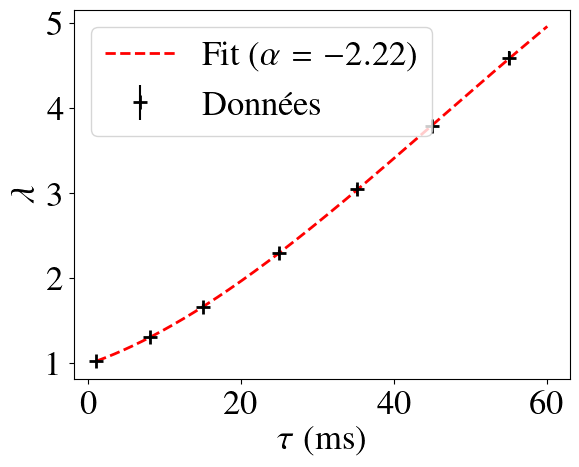

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# === ODE ===
def ode(t, lmbda, dotl0, omega, lmbda0, alpha, gamma):
    """Équation différentielle avec amortissement."""
    rhs = np.sqrt(dotl0**2 + (2*omega**2/alpha) * (lmbda0**(-alpha) - lmbda[0]**(-alpha)))
    return rhs * np.exp(-gamma * t)   # facteur d'amortissement

# === Solution numérique pour un jeu de paramètres ===
def solve_lambda(tau, dotl0, omega, lmbda0, alpha, gamma):
    sol = solve_ivp(
        lambda t, y: ode(t, y, dotl0, omega, lmbda0, alpha, gamma),
        [tau[0], tau[-1]], [lmbda0],
        t_eval=tau, rtol=1e-8, atol=1e-8
    )
    return sol.y[0]

# === Fonction modèle pour curve_fit ===
def model(tau, dotl0, omega, lmbda0, alpha, gamma):
    return solve_lambda(tau, dotl0, omega, lmbda0, alpha, gamma)

# === Données expérimentales ===
tau = np.array([1.05834885164494, 8.02268495005925, 15.061367868630438,
       24.973618870266915, 35.11102646577507, 44.945403758252915, 55.006066249083005])

lambda_exp = np.array([1.022346368715084, 1.305400372439479, 1.6629422718808193,
        2.2960893854748607, 3.040968342644321, 3.7858472998137804, 4.582867783985103])

errer = np.array([
    (1.0372439478584727 - 1.0074487895716953) / 2,
    (1.3351955307262573 - 1.2756052141527006) / 2,
    (1.6927374301675986 - 1.6405959031657362) / 2,
    (2.333333333333334 - 2.258845437616388) / 2,
    (3.0782122905027935 - 2.9813780260707636) / 2,
    (3.845437616387337 - 3.7262569832402237) / 2,
    (4.664804469273744 - 4.500931098696462) / 2
])

# === Ajustement avec barres d'erreur ===
p0 = [0.1, 1.0, lambda_exp[0], 0.5, 0.01]  # dotλ0, ω, λ0, α, γ
params, cov = curve_fit(model, tau, lambda_exp, p0=p0, sigma=errer, absolute_sigma=True, maxfev=5000)

dotl0_fit, omega_fit, lmbda0_fit, alpha_fit, gamma_fit = params
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)
print("α =", alpha_fit)
print("γ =", gamma_fit)

# === Tracé ===

# === Tracé ===
tauNN = np.linspace(tau[0], 60, 500)  # vecteur dense pour tracé
lambda_fit = model(tauNN, *params)  # utiliser tauNN, pas tauN

plt.errorbar(tau, lambda_exp, yerr=errer, fmt="k+", markersize=10,
             markeredgewidth=2, label="Données")
plt.plot(tauNN, lambda_fit, "r--", linewidth=2, label=fr"Fit ($\alpha={alpha_fit:.2f}$)")

plt.xlabel(r"$\tau$ (ms)")
plt.ylabel(r"$\lambda$")
plt.legend()
plt.show()



In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# === ODE ===
def ode(t, lmbda, dotl0, omega, lmbda0, alpha, gamma):
    rhs = np.sqrt(dotl0**2 + (2*omega**2/alpha) * (lmbda0**(-alpha) - lmbda[0]**(-alpha)))
    return rhs * np.exp(-gamma * t)

# === Solution numérique pour un jeu de paramètres ===
def solve_lambda(tau, dotl0, omega, lmbda0, alpha, gamma):
    sol = solve_ivp(
        lambda t, y: ode(t, y, dotl0, omega, lmbda0, alpha, gamma),
        [0, tau[-1]],       # commence à tau=0
        [lmbda0],
        t_eval=tau, rtol=1e-8, atol=1e-8
    )
    return sol.y[0]

# === Fonction modèle pour curve_fit ===
def model(tau, dotl0, omega, lmbda0, alpha, gamma):
    return solve_lambda(tau, dotl0, omega, lmbda0, alpha, gamma)

# === Données expérimentales ===
tau = np.array([1.05834885164494, 8.02268495005925, 15.061367868630438,
       24.973618870266915, 35.11102646577507, 44.945403758252915, 55.006066249083005])

lambda_exp = np.array([1.022346368715084, 1.305400372439479, 1.6629422718808193,
        2.2960893854748607, 3.040968342644321, 3.7858472998137804, 4.582867783985103])

errer = np.array([
    (1.0372439478584727 - 1.0074487895716953) / 2,
    (1.3351955307262573 - 1.2756052141527006) / 2,
    (1.6927374301675986 - 1.6405959031657362) / 2,
    (2.333333333333334 - 2.258845437616388) / 2,
    (3.0782122905027935 - 2.9813780260707636) / 2,
    (3.845437616387337 - 3.7262569832402237) / 2,
    (4.664804469273744 - 4.500931098696462) / 2
])

# === Ajustement ===
p0 = [0.1, 1.0, lambda_exp[0], 0.5, 0.01]
params, cov = curve_fit(model, tau, lambda_exp, p0=p0, sigma=errer, absolute_sigma=True, maxfev=5000)

dotl0_fit, omega_fit, lmbda0_fit, alpha_fit, gamma_fit = params
print("dotλ0 =", dotl0_fit)
print("ω∥ =", omega_fit)
print("λ0 =", lmbda0_fit)
print("α =", alpha_fit)
print("γ =", gamma_fit)

# === Tracé ===
tauNN = np.linspace(0, 60, 500)  # commence à tau=0
lambda_fit = model(tauNN, *params)

plt.errorbar(tau, lambda_exp, yerr=errer, fmt="k+", markersize=10,
             markeredgewidth=2, label="Données")
plt.plot(tauNN, lambda_fit, "r--", linewidth=2, label=fr"Fit ($\alpha={alpha_fit:.2f}$)")
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel(r"$\lambda$")
plt.legend()
plt.show()


ValueError: operands could not be broadcast together with shapes (2,) (7,) 

/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_33440/522414688.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(tau_fit, model3D(tau_fit, *params3D), "r--", color= colors["colorSix"], linewidth=4 )# label="Fit ($\\alpha=1/2$)")


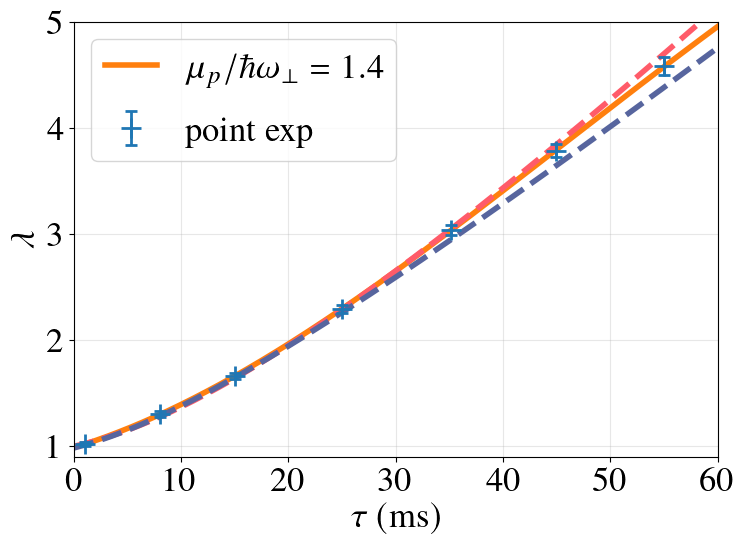

In [39]:
colors = {
    "colorOne": "#443E46",
    "colorTwo": "#FFFFFF",
    "colorThree": "#908CA4",
    "colorFour": "#57659E",
    "colorFive": "#C57284",
    "colorSix": "#FF5B69"
}


# Style LaTeX si tu veux cohérent avec newtx
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
    "font.size": 25
})

plt.figure(figsize=(8,6))


plt.plot(tauNN, model(tauNN, *params), "-", color='#ff7f0e', linewidth=4, label=fr"$\mu_p/\hbar\omega_\perp = 1.4 $")#={alpha_fit:.2f}$)")
plt.plot(tau_fit, model3D(tau_fit, *params3D), "r--", color= colors["colorSix"], linewidth=4 )# label="Fit ($\\alpha=1/2$)")
plt.plot(tau_fit, model1D(tau_fit, *params1D)+0.04, "--", color= colors["colorFour"], linewidth=4 )#, label="Fit ($\\alpha=1$)")

# Tracé avec barres d’erreurs
plt.errorbar(
    tau, lamb, yerr=errer,
    fmt="+",                # 'k' noir, '+' marqueur
    color = '#1f77b4',
    markeredgewidth=2,
    markersize=15,           # taille du +
    elinewidth=2,            # épaisseur des barres
    capsize=4,               # petits "chapeaux" en haut et bas
    capthick=2,
    label = "point exp"
)

# Axes
plt.xlabel(r"$\tau \, (\mathrm{ms})$")
plt.ylabel(r"$\lambda$")

plt.legend(
    loc="upper left",     # position : 'upper right', 'lower left', etc.
    fontsize=25,           # taille du texte
    #frameon=False,         # pas de boîte autour
    handlelength=1.5,        # longueur du trait dans la légende
    labelspacing=0.8       # espacement vertical entre entrées
)

plt.xlim(0, 60)       # limite de l'axe des x
plt.ylim(0.9, 5)        # limite de l'axe des y

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fit_lambda_vs_tau.pdf", dpi=300, bbox_inches="tight")  # PDF pour article
plt.show()

<Figure size 800x600 with 0 Axes>

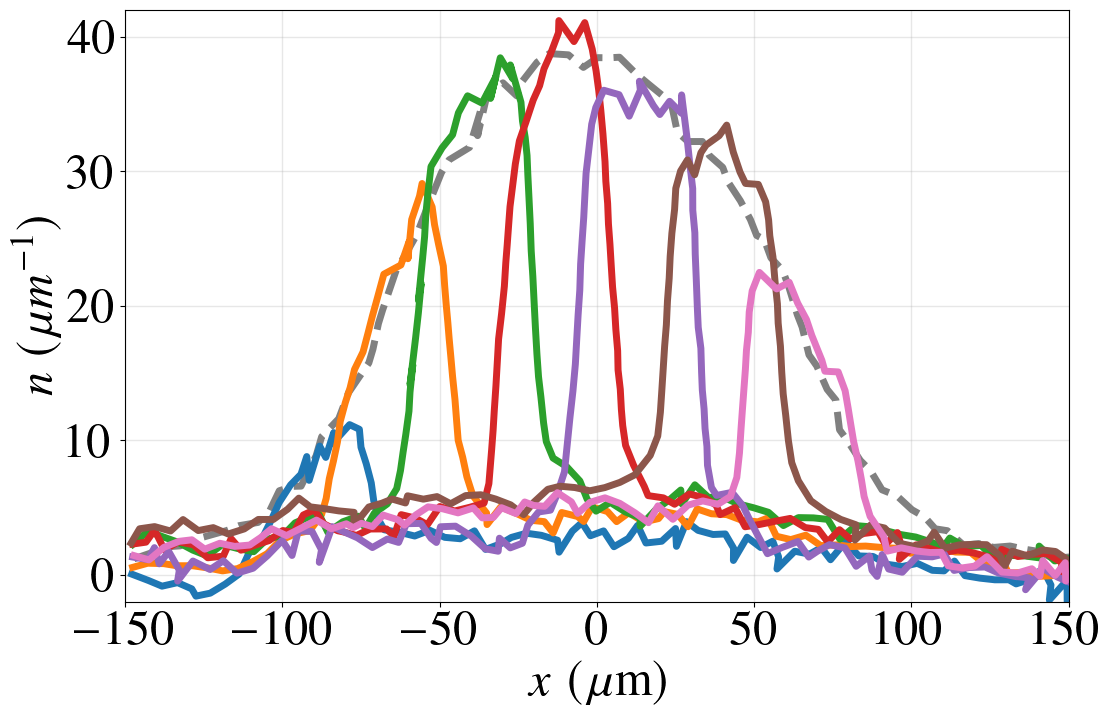

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# === Configuration LaTeX pour matplotlib ===
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
    "font.size": 35
})

plt.figure(figsize=(8,6))

# === Liste des fichiers à tracer ===
files = ["profil_ini.csv"] + [f"profil{i}.csv" for i in range(1, 8)]

# === Couleurs et styles ===
colors = ["0.5"] + ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]
linestyles = ["--"] + ["-"]*7  # profil_ini en gris dash, les autres en continu

# === Création de la figure ===
fig, ax = plt.subplots(figsize=(12,8))

for i, f in enumerate(files):
    df = pd.read_csv(f, sep=";", decimal=",", header=None, names=["x","y"])
    ax.plot(df["x"], df["y"], color=colors[i], linestyle=linestyles[i], linewidth=5)#, label=f.split(".")[0])

# === Labels et légende ===
ax.set_xlabel(r"$x \ (\mathrm{\mu m})$")
ax.set_ylabel(r"$n \ (\mu m^{-1})$")

#ax.legend()
ax.grid(True, alpha=0.3, linewidth=1.0)
plt.xlim(-150, 150)       # limite de l'axe des x
plt.ylim(-2, 42)        # limite de l'axe des y
plt.tight_layout()
plt.savefig("profils.pdf", dpi=300, bbox_inches="tight")  # PDF pour article
plt.show()


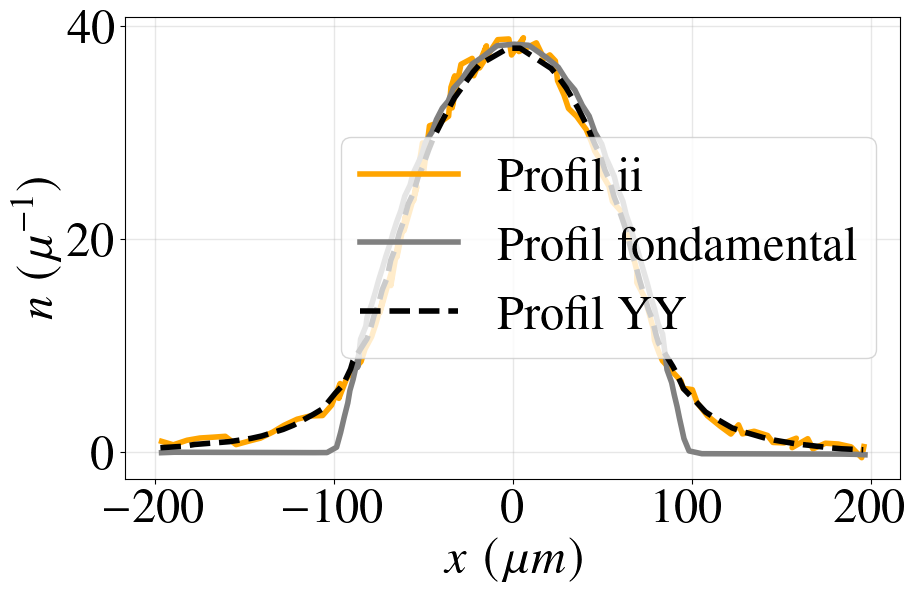

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Chargement des fichiers ---
dff = pd.read_csv("profil_fonda.csv", sep=";", decimal=",", header=None, names=["x","y"])
dfYY = pd.read_csv("profil_YY.csv", sep=";", decimal=",", header=None, names=["x","y"])
dfi = pd.read_csv("profil_ii.csv", sep=";", decimal=",", header=None, names=["x","y"])

# --- Paramètres LaTeX pour matplotlib ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
    "font.size": 35
})

# --- Création de la figure ---
fig, ax = plt.subplots(figsize=(10,6))

# Tracés
ax.plot(dfi["x"], dfi["y"], color="orange", linestyle="-", linewidth=4, label=r"Profil ii")
ax.plot(dff["x"], dff["y"], color="grey", linestyle="-", linewidth=4, label=r"Profil fondamental")
ax.plot(dfYY["x"], dfYY["y"], color="black", linestyle="--", linewidth=4, label=r"Profil YY")


# Labels
ax.set_xlabel(r"$x\ (\mu m)$")
ax.set_ylabel(r"$n\ (\mu m^{-1})$")

# Grille
ax.grid(True, alpha=0.3, linewidth=1.0)

# Légende
#ax.legend()

plt.show()


x0 = -0.25839301663520853 y0 = 0.7101157039853325 a = 87.24402457616772 b = 34.334294922844755


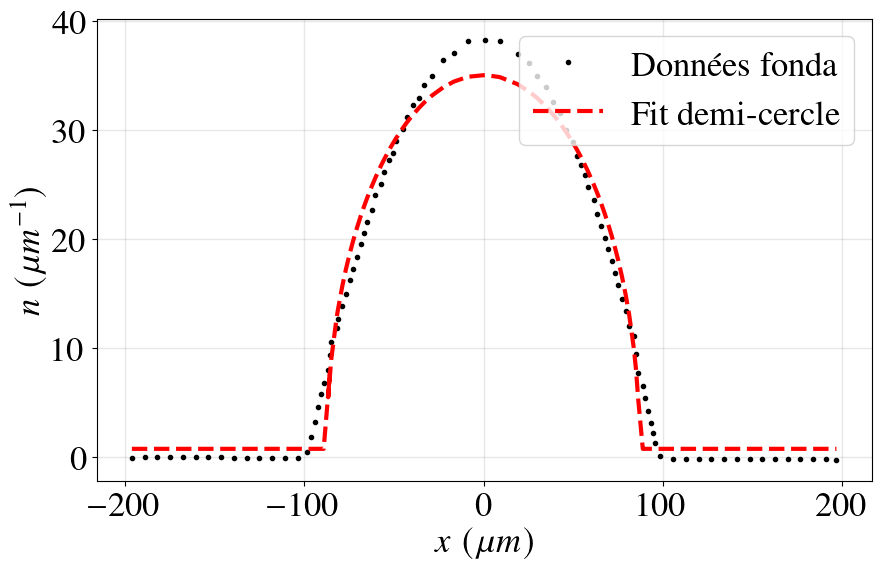

38.27186238713816


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Chargement ---
dff = pd.read_csv("profil_fonda.csv", sep=";", decimal=",", header=None, names=["x","y"])

def half_ellipse(x, x0, y0, a, b):
    """
    Demi-ellipse supérieure centrée en (x0, y0)
    a : demi-axe horizontal
    b : demi-axe vertical
    Renvoie 0 si en dehors de l'ellipse
    """
    inside = 1 - ((x - x0) / a)**2
    inside[inside < 0] = 0
    return y0 + b * np.sqrt(inside)



# --- Estimation initiale des paramètres ---
x0_init = 0 #(dff["x"].min() + dff["x"].max()) / 2
y0_init = 0 # dff["y"].min()
a=  100 #(dff["x"].max() - dff["x"].min()) / 2
b= 40 #(dff["x"].max() - dff["x"].min()) / 2
p0 = [x0_init, y0_init, a , b ]

# --- Ajustement ---
params, cov = curve_fit(half_ellipse, dff["x"], dff["y"], p0=p0)
x0_fit, y0_fit, a , b  = params
print("x0 =", x0_fit, "y0 =", y0_fit, "a =", a , "b =", b )

# --- Création du tracé ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
    "font.size": 25
})

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(dff["x"], dff["y"], "k.", label="Données fonda")
ax.plot(dff["x"], half_ellipse(dff["x"], *params), "r--", linewidth=3, label="Fit demi-cercle")

ax.set_xlabel(r"$x\ (\mu m)$")
ax.set_ylabel(r"$n\ (\mu m^{-1})$")
ax.grid(True, alpha=0.3, linewidth=1.0)
ax.legend()
plt.show()

print (dff["y"].max())

In [143]:
import numpy as np
from numpy.linalg import solve, norm
from scipy.linalg import eigh, inv

# --- Constantes ---
hbar = 1.05457182e-25   # um^2.kg/ms
mass = 1.44e-25         # kg (masse de Rb87)
kB = 1.380649e-26       # um^2.ms^-2.kg.nK^{-1}
a3D = 5.3e-3            # um
om_perp = 2 * np.pi * 5 # kHz

# --- Constantes dérivées ---
g = 2 * hbar * a3D * om_perp
c = mass / hbar**2 * g
gbar = g / hbar

# --- Fonctions auxiliaires ---
def f_varphimat(lam_discr, gb):
    L = len(lam_discr)
    varphi = lambda lam: 2 * gb / (gb**2 + lam**2)
    varphimat = np.zeros((L, L))
    for i in range(L):
        for j in range(i+1):
            varphimat[i,j] = varphi(lam_discr[i]-lam_discr[j])
            varphimat[j,i] = varphimat[i,j]
    return varphimat

def f_dlam(lam_discr):
    L = len(lam_discr)
    dlam = np.zeros(L)
    dlam[1:-1] = 0.5 * (lam_discr[2:] - lam_discr[:-2])
    dlam[0] = 0.5 * (lam_discr[1] - lam_discr[0])
    dlam[-1] = 0.5 * (lam_discr[-1] - lam_discr[-2])
    return dlam

def dress(gb, lam_discr, n_discr, f_discr):
    varphimat = f_varphimat(lam_discr, gb)
    dlam = f_dlam(lam_discr)
    A = np.eye(len(lam_discr)) - 0.5/np.pi * varphimat @ np.diag(n_discr*dlam)
    return solve(A, f_discr)

def charge_density(gb, lam_discr, n_discr, f_discr, beta=None):
    L = len(lam_discr)
    varphimat = f_varphimat(lam_discr, gb)
    dlam = f_dlam(lam_discr)
    A = np.eye(L) - 0.5/np.pi * varphimat @ np.diag(n_discr*dlam)
    dressed = solve(A, f_discr)
    if beta is None:
        return 0.5/np.pi * np.dot(dlam, n_discr * dressed)
    else:
        mesure = np.zeros(L)
        for i, val in enumerate(beta):
            mesure += lam_discr**i * val / np.math.factorial(i)
        mesure_time_dressed = mesure * dressed
        return 0.5/np.pi * np.dot(dlam, n_discr * mesure_time_dressed)

# --- Yang-Yang fonctions ---
def fun1(z):
    if z > 0:
        return np.log(1 + np.exp(-z))
    else:
        return np.log(1 + np.exp(z)) - z

def fun2(z):
    if z < 0:
        return 1. / (1 + np.exp(z))
    else:
        return np.exp(-z) / (1 + np.exp(-z))

vec_fun1 = np.vectorize(fun1)
vec_fun2 = np.vectorize(fun2)

def yangyang(gb, beta, lam_discr):
    L = len(lam_discr)
    varphimat = f_varphimat(lam_discr, gb)
    dlam = f_dlam(lam_discr)
    
    bare_E = 0.5*beta[2]*lam_discr**2 + beta[1]*lam_discr + beta[0]
    eps = bare_E.copy()
    n = vec_fun2(eps)
    
    diff = 1.0
    while diff > 1e-12:
        old_n = n.copy()
        eps = bare_E - 0.5/np.pi * varphimat @ np.diag(vec_fun1(eps)) @ dlam
        n = vec_fun2(eps)
        diff = norm(n - old_n)
    
    eps = bare_E - 0.5/np.pi * varphimat @ np.diag(vec_fun1(eps)) @ dlam
    n = vec_fun2(eps)
    return n

# --- Exemple pour veff ---
def veff(gb, lam_discr, n_discr):
    L = len(lam_discr)
    varphimat = f_varphimat(lam_discr, gb)
    dlam = f_dlam(lam_discr)
    A = np.eye(L) - 0.5/np.pi * varphimat @ np.diag(n_discr*dlam)
    onedr = solve(A, np.ones(L))
    iddr = solve(A, lam_discr.copy())
    return iddr / onedr

import numpy as np
from scipy.interpolate import interp1d

# --- Paramètres globaux ---
theta_max = 10.0  # à définir selon ton problème

# --- modèle préliminaire pour un T et mu ---
def model_prel_mu(T, mu):
    T = np.asarray(T, dtype=float)
    mu = np.asarray(mu, dtype=float)
    theta_discr_integrer = np.linspace(-theta_max, theta_max, 600)
    mup = mu * kB
    print(mup) 
    print(T)
    beta = np.array([-mup/(kB*T[0]), 0.0, mass/(kB*T[0])], dtype=float)  # beta doit être 1D
    nu_discr = yangyang(gbar, beta, theta_discr_integrer)
    densite = mass/hbar * charge_density(gbar, theta_discr_integrer, nu_discr, np.ones(len(theta_discr_integrer)))
    return densite


# --- modèle avec interpolation ---
def model_prel_mu_1(T, mu):
    theta_discr_integrer = np.linspace(-theta_max, theta_max, 600)
    mup = mu * kB
    beta = np.asarray([-mup/(kB*T), 0.0, mass/(kB*T)], dtype=float)
    theta_discr_integrer = np.asarray(theta_discr_integrer, dtype=float)
    nu_discr = np.asarray(yangyang(gbar, beta, theta_discr_integrer), dtype=float)
    f_discr = np.ones(len(theta_discr_integrer), dtype=float)

    densite = mass/hbar * charge_density(gbar, theta_discr_integrer, nu_discr, f_discr, beta)

    
    lam_discr = np.linspace(theta_discr_integrer[0], theta_discr_integrer[-1], 600)
    nu_discr_interp = nu_fun(lam_discr)
    
    densite = mass/hbar * charge_density(gbar, lam_discr, nu_discr_interp, np.ones(len(lam_discr)))
    return densite

# --- modèle pour une liste de T et mu ---
def model_mu(list_T, list_mu):
    list_T = np.array(list_T)
    list_mu = np.array(list_mu)
    OutDensite = np.zeros(len(list_T))
    
    # On calcule le premier élément
    OutDensite[0] = model_prel_mu(list_T[0], list_mu[0])
    
    # Ici tu peux ajouter un plot si nécessaire (optionnel)
    # import matplotlib.pyplot as plt
    # plt.scatter(list_mu, OutDensite, s=50, edgecolor='k')
    # plt.xlabel("mu")
    # plt.ylabel("densite")
    # plt.show()
    
    return OutDensite


In [135]:
from scipy.optimize import curve_fit
import numpy as np
T = 100 
n_p = 38.2
mu_initial = 50
# Supposons que T, n_p et mu_initial soient des scalaires ou des arrays
# On reshape pour que ce soit compatible avec curve_fit (1D arrays)
T_array = np.array([T])          # shape (1,)
n_p_array = np.array([n_p])      # shape (1,)
mu_guess = np.array([mu_initial])  # shape (1,)

# Définition d'une fonction wrapper si nécessaire
def model_mu_wrapper(T_input, mu_param):
    return model_mu(np.array([T_input]), np.array([mu_param]))

# Utilisation de curve_fit
popt, pcov = curve_fit(model_mu_wrapper, T_array, n_p_array, p0=mu_guess)

mu_fit = popt[0]  # valeur ajustée de mu


6.903245e-25
[100.]
6.903245102866366e-25
[100.]
1.3053783536201526e-24
[100.]
1.3053783730718057e-24
[100.]
1.3226251627396222e-24
[100.]
1.322625182448273e-24
[100.]
1.3226339396772344e-24
[100.]
1.3226339593860159e-24
[100.]
1.3226339396798563e-24
[100.]


/var/folders/sc/1jlhfymx3sg5vz8q1fx87pvr0000gn/T/ipykernel_33440/3363555014.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_mu_wrapper, T_array, n_p_array, p0=mu_guess)


In [141]:
import numpy as np
import time

# --- Constantes (à adapter si déjà définies) ---
hbar = 1.05457182e-25   # um^2.kg/ms
mass = 1.44e-25         # kg
kB = 1.380649e-26       # um^2.ms^-2.kg.nK^{-1}
a3D = 5.3e-3            # um
om_perp = 2 * np.pi * 5 # kHz
gbar = 1.0  # à définir selon ton cas

# --- Discrétisation de theta ---
thetamin = -10
thetamax = 10
L = 600
theta_discr = np.linspace(thetamin, thetamax, L)

# --- Paramètres ---
mu = 49
T = 90
mup = mu * kB
beta = np.array([-mup / (kB * T), 0.0, mass / (kB * T)])

# --- Yang-Yang : nu_discr (fonction yangyang à définir comme précédemment) ---
nu_discr = yangyang(gbar, beta, theta_discr)

# --- Calcul de rho_s_discr ---
start_time = time.time()
rho_s_discr = 0.5 / np.pi * mass / hbar * dress(gbar, theta_discr, nu_discr, np.ones(L))
end_time = time.time()
print(f"rho_s_discr computed in {end_time - start_time:.3f} s")

# --- rho_discr ---
rho_discr = nu_discr * rho_s_discr

# --- Affichage si besoin ---
print(rho_discr)

rho_s_discr computed in 0.204 s
[0.0014154  0.00147414 0.00153516 0.00159855 0.00166438 0.00173275
 0.00180375 0.00187747 0.00195401 0.00203347 0.00211594 0.00220155
 0.00229039 0.00238258 0.00247823 0.00257748 0.00268044 0.00278723
 0.00289801 0.00301289 0.00313203 0.00325557 0.00338366 0.00351646
 0.00365413 0.00379682 0.00394473 0.00409801 0.00425685 0.00442145
 0.00459199 0.00476868 0.00495171 0.00514131 0.00533769 0.00554107
 0.0057517  0.00596981 0.00619564 0.00642946 0.00667152 0.0069221
 0.00718148 0.00744993 0.00772777 0.00801528 0.0083128  0.00862064
 0.00893913 0.00926862 0.00960946 0.00996201 0.01032665 0.01070377
 0.01109375 0.01149701 0.01191397 0.01234506 0.01279072 0.01325141
 0.01372759 0.01421976 0.0147284  0.01525403 0.01579716 0.01635834
 0.01693812 0.01753705 0.01815574 0.01879476 0.01945474 0.0201363
 0.02084009 0.02156676 0.022317   0.02309148 0.02389094 0.02471608
 0.02556766 0.02644643 0.02735318 0.02828869 0.02925378 0.03024928
 0.03127604 0.03233492 0.0334268

In [3]:
import matplotlib.pyplot as plt

# Data provided (last incomplete line removed)
raw_data = """
-3,7625443878338736; 1,584928711339053
-3,777229835889891; 1,1823314538477696
-3,770936072437312; 0,9347858008099195
-3,766740230135593; 0,649528997774464
-3,7638031405243897; 0,3599486234016993
-3,712194280213243; 1,3770051985712612
-3,6520538738886015; 0,17914044950285657
-3,6337844771998657; 0,5127006813350476
-3,628627087704002; 0,7859711128525966
-3,6200471281254867; 1,5756042965279953
-3,584221090010807; 0,7753133253968407
-3,5692734018109324; 0,44897039206408706
-3,5693449218501665; 0,18775847721897065
-3,556648412028081; 0,0009832048086444445
-3,554850193898773; 0,8479752704295223
-3,5254792977867386; 0,4261920045685166
-3,512891770881581; 0,1379487774810002
-3,501595272376952; -0,05210794083704329
-3,476760906616777; 0,43331903242455994
-3,4611430491603774; 0,1781231385999682
-3,451912196096595; 0,694323645910746
-3,4485555222552198; 1,1279015527247118
-3,440863144702068; 0,8997545114778127
-3,4179332345795146; 0,4822460516521012
-3,409194525424806; 0,1667746048703762
-3,401701949886022; 1,0178167385996986
-3,3987648602748184; 0,7933739335802379
-3,3719114695438153; 0,5647672185179431
-3,3786248172265663; 0,18210572239389222
-3,3524507533444132; 1,005021968239312
-3,3256523081673617; 1,286658806337396
-3,328274709605936; 1,0161141557691593
-3,282120444287025; 1,332880622641639
-3,2842183654378845; 1,9776213168452053
-3,235406733327884; 1,4810440774830944
-3,2003015194035003; 1,6934383419850256
-3,155246165163611; 1,778254956452244
-3,1772243867440446; 1,6426081201355025
-3,116384673369116; 1,7174475857592633
-3,085964816681652; 1,4015902120578936
-3,0741265473303727; 1,1441217407687887
-3,0600205251160215; 0,19761124830541732
-3,024495726961465; 1,1472511828795966
-3,0148775653775246; 0,9391724106433443
-2,9692679526650863; 1,0613244413460912
-2,965906510821095; 0,34004646962684504
-2,9338655332443304; 1,5931300740277408
-2,932187196323643; 1,2712331233063416
-2,921487798454259; 0,9989837705098523
-2,887711267925419; 1,5819085695960844
-2,887711267925419; 1,3450446810386332
-2,8751237410202615; 1,062117553216261
-2,856315105940477; 0,5384664409538331
-2,841557002606508; 1,42592603575266
-2,825706042800013; 1,0982494517840884
-2,8144238890553908; 0,8837883820295929
-2,792752731623353; 1,4528558399992662
-2,774703248599115; 1,7614375692299902
-2,7775004768002614; 1,0357350688314853
-2,745985039067348; 1,4486377014683356
-2,728548983280204; 1,762059259226202
-2,702095196577936; 1,320884892744214
-2,6844227084071237; 1,8333539144283648
-2,6828143021914648; 1,5380134880452339
-2,677919152839459; 1,2248243687837856
-2,6527440990291438; 1,9274495212189429
-2,643932830195533; 1,707930783555856
-2,613582904213098; 2,6039363098490007
-2,598198149106794; 1,416479944363907
-2,5856106222016364; 2,328869100046944
-2,5585474393555474; 1,1540657529971838
-2,5442516052275463; 1,4342652693913642
-2,5366591286815794; 0,8954252884132679
-2,5268688299775675; 1,6465831682931125
-2,51428130307241; 2,3386388812684338
-2,501693776167252; 1,3287111893199253
-2,501693776167252; 1,091847300762474
-2,483629857686475; 0,08625804345997423
-2,487008328111235; 2,2386816626416604
-2,451837297052707; 1,2394504689544519
-2,4399109781646993; 0,1832343268675345
-2,4093852455294296; 1,3456149916963192
-2,398088747024801; 1,0998684059583788
-2,4027418285517075; 0,8742605118603493
-2,4051894032277104; 2,4841842162828662
-2,3539559603856657; 1,3273012321036326
-2,3737205859648167; 0,9589893227079713
-2,319174636042467; 1,3527027714465376
-2,2373557111589424; 2,5488908414342433
-2,1951175653216355; 2,367864134082186
-2,17050195715155; 2,127742966726391
-2,1744180766331542; 1,3272468781718167
-2,1618305497279966; 2,007992286092062
-2,156935400375991; 1,2041565405330346
-2,125613805649999; 2,2262664539254047
-2,1345575747668217; 1,5023322500807197
-2,0980537467418645; 2,3289764828644763
-2,059032413335876; 3,121919466126201
-2,042249044128999; 3,5312740699967833
-2,0296615172238415; 2,0873813921426567
-1,9562342769437557; 3,09491962372865
-1,9400503137799814; 2,865894203756877
-1,9377026401111626; 2,647134345040463
-1,9004295743308903; 2,910878319320574
-1,9027372875968358; 2,6435678696644587
-1,9090310510494146; 2,4187315631360278
-1,912177932775704; 2,2248914481801876
-1,8250589965636919; 1,975884526191905
-1,8135756386853026; 2,3111096340711903
-1,7993563953294762; 2,605632612982614
-1,7881208620548725; 2,9690948776932977
-1,7766522264301736; 3,2032421693582016
-1,7548338464612336; 2,686855452507885
-1,7442043792968787; 2,4241817121028326
-1,7283337898187967; 3,1490403203868667
-1,726511910924629; 2,854543315140937
-1,6980795584853476; 2,637187181159657
-1,7041022986313559; 2,3769575919441586
-1,694460337786496; 3,3852271584619977
-1,6795884078504026; 3,0193651075689587
-1,6514063337238554; 2,696210176559763
-1,6499377889182534; 3,340803155165055
-1,6532012218195908; 2,480197236701084
-1,6334341425314913; 3,0687951139951934
-1,6117556239726087; 3,404644295358896
-1,6247627351079381; 2,675574307480897
-1,594459429595522; 3,727514599104669
-1,575811241587881; 4,000518143502628
-1,5637831603229526; 4,270561438767103
-1,5558809906547149; 4,569618817763963
-1,550496326367508; 4,77174342289662
-1,5291907715687785; 4,063352790998746
-1,517658339511422; 4,3248643247569625
-1,495530792214987; 4,490400440973694
-1,4897329010344293; 4,139685076167474
-1,4611248853408894; 4,372040427768908
-1,4551807754134538; 4,594302736477271
-1,452733200737451; 4,870350649403527
-1,4506352795865913; 5,504136626390746
-1,435949831530574; 5,746581595596027
-1,4275581469271357; 6,094812769384319
-1,4283973153874796; 4,590356888910396
-1,4212643834745569; 4,917755796098287
-1,4170685411728376; 6,40897815724372
-1,4086768565693992; 6,742853943846709
-1,405180321317966; 5,201491342552099
-1,3981872508151012; 7,078552412484058
-1,3415433797418919; 6,451267206304351
-1,3235944987845372; 7,516798332012023
-1,3163683259315766; 7,26089126250994
-1,2995849567246998; 7,707928757741939
-1,2177660318411752; 7,299902309772353
-1,1880136955198934; 9,075803456394778
-1,1732255520229251; 8,776346491060238
-1,1716117665222638; 9,36867853085078
-1,1875559672687968; 7,395054789556495
-1,1779055299748427; 8,481169819850928
-1,1779055299748427; 8,312494020423651
-1,1414017019498854; 9,156364717829765
-1,0960866050913185; 9,269371260856408
-1,0755269778128942; 9,60370458046901
-1,0520302609232668; 9,861879719510307
-1,0362958522918198; 10,221424944763786
-1,0212607507106588; 10,556436964030315
-1,0226593648112323; 8,531710390679489
-1,0053239110909713; 10,952621060373453
-1,0135683731575074; 8,827912705466467
-1,0048270350289257; 9,29188889820894
-0,986994705246619; 10,731077219603085
-0,9744071783414614; 11,218612166361174
-0,9436376681288539; 10,066408663605594
-0,9253158234113465; 10,27756001909237
-0,9114695438156732; 10,595897794585445
-0,887693104105931; 12,43281040714828
-0,9051757803630944; 10,84630463453769
-0,8742005916062849; 12,638400850896192
-0,8957351351842262; 11,269018508667823
-0,8685121107266434; 13,194929677441884
-0,8683123087122753; 12,883215389859767
-0,8779028054019196; 11,652009217903514
-0,8361541744998133; 13,492034990220116
-0,8485319092898851; 12,517675801404158
-0,823916301119799; 13,78451140382524
-0,8422381458373063; 13,194258198420002
-0,8149651708761314; 14,063779003000478
-0,7981818016692546; 14,236269718313611
-0,7794109282141948; 13,79123081174604
-0,7608006611630289; 14,04493306162765
-0,7552551073516653; 13,571430563150917
-0,7213978875477931; 14,135804871822154
-0,7268524825400284; 13,823860612767414
-0,713265945563033; 14,794570333284168
-0,7125866187141829; 14,459996423802309
-0,7233559472885958; 13,601399209122247
-0,6873232313817264; 15,206854628244223
-0,6755033648475601; 15,67485914623472
-0,6691596508913893; 15,376813964673254
-0,6943347047017046; 14,237913214904841
-0,6705582649919624; 16,033554089309938
-0,6673809786113125; 14,766655949298329
-0,6396722036043068; 15,090462296477797
-0,6293490995286488; 15,668303142638285
-0,6327457337728974; 15,36269272047354
-0,6289494954999135; 16,206020313805038
-0,6201582068677398; 15,976555074462269
-0,6324460307513462; 14,77348501732492
-0,6151105770310847; 16,566678049340616
-0,5799980019798561; 16,244721458023886
-0,5751028526278503; 16,58572784049254
-0,5677601285998417; 15,981106060538448
-0,5458318575229999; 16,35438515118718
-0,5346066170794392; 16,896219177485886
-0,5464312635661024; 16,600469429039126
-0,5202571996839493; 17,641587560101108
-0,5212562097557871; 17,29769732875981
-0,5170603674540679; 17,133039760600862
-0,5050722465920128; 17,965301002869886
-0,4773232727142567; 17,520672853207632
-0,49608115594547186; 17,300972761591105
-0,4615154074598804; 18,226848137315972
-0,4625144175317182; 17,88379685717382
-0,45915774369034335; 17,762278042236208
-0,4463304543679447; 18,549023502886328
-0,4168018198235144; 18,183196972414354
-0,43034629321853757; 17,857232240589735
-0,40995597185755184; 18,804348567243856
-0,39957678300593; 18,471910455658204
-0,3914648212226055; 19,063070163859578
-0,37067209159408687; 18,634124161502246
-0,3571987757585662; 18,38811075451567
-0,36601004459217634; 18,978716250918765
-0,32740829541635996; 18,35190578982707
-0,26079122994906356; 18,667351728654197
-0,27250270186814873; 17,48701551143209
-0,2573843494476682; 17,829355880948903
-0,23978512201545676; 18,919406083325427
-0,20945267870927875; 19,094098028653566
-0,18652123501863205; 19,362747976913266
-0,16198721267107974; 19,627681129551664
-0,12915474666012816; 19,927567781776432
-0,11485891253212799; 20,243835208473676
-0,11453922930913762; 19,600102937770757
-0,08139207512555746; 19,891724527631087
-0,07460879673777843; 20,453709677299393
-0,06915420174554221; 20,154473326939986
-0,07439900462269122; 19,59992585031729
-0,051321871963235566; 20,714084237374816
-0,05341979311409517; 19,823614149750437
-0,03267368395559522; 20,401997001038577
-0,029410251054257763; 20,235757724020704
-0,042930187359797145; 20,02742249862284
0,021298475566520203; 20,257973842603352
0,026301210618568938; 19,069684333148842
0,046860837896994134; 18,82852159956075
0,045182500976305384; 20,01784282095391
0,05881898845689282; 18,576207301665576
0,06301483075861203; 19,72020873526656
0,0865814783532679; 19,561181376189616
0,1284999409675862; 19,77953774195069
0,1279005349244846; 19,50421384953656
0,13781378871426053; 19,283929085458556
0,1508190012784132; 19,08489890754482
0,17205678009971948; 20,095430270741126
0,1710577700278817; 19,752006123399354
0,18629530259728266; 19,46517231269299
0,20014894331980315; 19,1672201934071
0,20042866613991617; 20,134777057514484
0,2151141141959334; 19,797623269113274
0,23049886930223806; 19,521489295794986
0,23039896829505313; 18,87652091160609
0,24109606075657908; 18,615310189495617
0,245983525415725; 19,265864364105038
0,2787510557720081; 19,005345305756588
0,2793504618151115; 18,109295238470203
0,28644343332516; 18,665021167504555
0,2834131027739186; 18,420426074924922
0,2879419484329171; 17,7983348509322
0,28548983280204165; 19,348334074370197
0,3005294753380747; 17,597016289755672
0,3032268025320368; 19,045152304605065
0,3304997774932117; 18,395612137941058
0,3304997774932117; 18,158748249383606
0,3304997774932117; 17,921884360826155
0,3426210996981789; 17,672350898268732
0,36175880264101945; 17,311451063890924
0,3805701622937292; 18,31406935987569
0,376654042812123; 18,045831877096084
0,39107725072428323; 17,766463146256175
0,39157259321823634; 17,48399766850675
0,3992316704356593; 17,055660886461723
0,4215172797305051; 16,841261268027203
0,4102207812258767; 18,340308445534067
0,4144166235275959; 18,09611830369656
0,4228083081310343; 17,797844361746876
0,4249062292818939; 17,539475651047663
0,43539583503619195; 17,29883795007518
0,44756377771117783; 17,076819607592604
0,468063464385291; 16,9555876361621
0,47315841575166484; 16,37733923767076
0,5046272330145589; 17,08835478288599
0,5098720358917079; 16,842589423928203
0,5319002079757338; 16,239144230826447
0,5444877348808914; 15,974913651394342
0,5444877348808914; 16,802501722626893
0,559772588980012; 15,722515990522403
0,5589109427930508; 15,424982576226487
0,5738586309929259; 15,030920550788077
0,5775882685944538; 14,730268928004781
0,5899794987837419; 14,51346801012259
0,5934392284009489; 14,354849806351764
0,6074253694066796; 15,531527428854982
0,6074253694066796; 15,29564231669653
0,6147680934346882; 15,072457855901842
0,6183345593911493; 14,766466985026753
0,6137191328592584; 14,570453780947783
0,6409921078204333; 16,198106819151935
0,6326004232169948; 15,313599395512789
0,6674259143212637; 16,019276884351434
0,6934401365919234; 15,84197937502212
0,7011325141450744; 15,558564093111812
0,7067269705473676; 15,30742017373224
0,713720041050232; 15,04911739985081
0,716517269251379; 13,470062487649388
0,7207131115530983; 14,779150873881324
0,7299439646168802; 14,477273753969815
0,7312027173073963; 13,269284877508529
0,7390699216231198; 14,15090134174158
0,7710632191737288; 13,865896618585788
0,7988882786482865; 13,626625743226986
0,8151195633417805; 13,948707267461618
0,8238109509667702; 13,412804435303295
0,8088257998892017; 12,850435371877587
0,8238109509667702; 12,507646004030178
0,828756050822367; 13,674344168678
0,8381966960012353; 12,26789973458119
0,8501387087061287; 12,012858090125453
0,8607896930104939; 11,718163989472647
0,8528821440572525; 13,241315892337957
0,8675675921132697; 11,467236785508156
0,8768583857813628; 11,206378195364254
0,8827192448694783; 10,9044813168349
0,8633717498115505; 13,023434742642168
0,9095260151304618; 10,899459129213971
0,9216939578054486; 10,686804414281807
0,9598761227510924; 10,480242261312538
0,9805325771595568; 11,550825040911356
0,9827201530604528; 11,343069479845626
1,031205441880319; 11,582000245015836
1,0228137572768805; 10,395470389685961
1,0423943546849044; 10,128749569930473
1,057379505762472; 9,802238185766397
1,0563804956906342; 11,400286938436555
1,0815555495009495; 10,079417728623769
1,086590560263013; 9,828778966007354
1,1305070430210078; 11,033069728945708
1,1444931840267376; 11,284999409675871
1,167446909559672; 10,637991942169991
1,1654723955353337; 10,997242084332736
1,1807572496344534; 10,321463039974342
1,1893564209451197; 10,031414690164869
1,1977481055485582; 9,797148422395793
1,1978050626838757; 9,485747713732847
1,2210173555295212; 9,07539376733588
1,2053328974016662; 10,390238505042499
1,2349368958637967; 9,351067977128828
1,2405039284601953; 8,751664810021737
1,2200183454576834; 9,862875836436059
1,2481904294835129; 8,60357008404055
1,2745642953800331; 8,821947778343704
1,283696422742599; 7,398829145988053
1,2871518222851908; 8,636394508451032
1,302361750628923; 7,09832992548861
1,339599851056681; 7,028849003752672
1,3626769837161365; 6,814277646820818
1,3689707471687154; 7,525851300100825
1,3752645106212942; 6,527339454931965
1,3836561952247326; 7,324176478260885
1,3878520375264518; 6,161446633523962
1,3983416432807498; 5,838591715035669
1,4067333278841883; 5,65029029277337
1,4631440966073015; 6,716937634610607
1,4731674976614082; 6,336398541484442
1,4735671016901435; 6,10415426711964
1,492254466563348; 7,010242977445531
1,514726316649866; 6,585614145356281
1,5250238050826566; 6,3438409139516025
1,5291994750656173; 5,451413075916388
1,5263148334831858; 7,169214191282558
1,5284127546340454; 6,908922884085317
1,5433604428339196; 5,097384642913401
1,546095232905576; 4,825450979452654
1,5582032349762507; 4,61120611069251
1,5458954308912087; 6,622947840713326
1,5570843436957924; 6,266008297205342
1,5968574321808395; 6,008819973288713
1,582958704556395; 4,979755243902517
1,5808607834055355; 4,721330015930924
1,6153957931196858; 6,290397311689674
1,6257240203239167; 5,796103768651072
1,6400687803297949; 5,58823589762099
1,6362459017882287; 6,057127052159288
1,655786538793378; 5,3614103288833554
1,6563859448364813; 4,767566796467516
1,6767196421448123; 4,421158087339453
1,6710713928924985; 5,75074974443428
1,6836589197976553; 5,449456165360125
1,6878547620993745; 5,203676677084246
1,7060367454068244; 4,1784086132147
1,727435541145593; 3,9954862223514596
1,7196033021823833; 3,665206818181108
1,741002097921152; 3,5418592841368657
1,7612820023794606; 4,010531889202312
1,7675757658320395; 3,7828494045555487
1,790159269985411; 3,5157634032730662
1,8200237946035296; 3,1594880384593864
1,836207757767304; 3,5742877512283293
1,834870621209613; 2,9101753314017813
1,849394690715564; 3,734425405577735
1,8647794458218687; 3,236500700246559
1,879012401080641; 2,860201275901936
1,8619822176207217; 3,5623303111712836
1,9057388587672222; 2,5631695266070196
1,9181016084062161; 2,3208966323114097
1,9584865905602635; 1,9183070817209078
1,9968785476209945; 2,899851799478636
1,9962491712757364; 1,8984012579932568
2,014031550554451; 3,2762452609655455
2,0182273928561703; 3,8802534248194824
2,0214242250860517; 3,558325658728137
2,03086487026492; 4,201625437732396
2,045666869495985; 2,870113431201414
2,0591868058015246; 3,2925931511322197
2,0521937352986592; 3,7634752835826326
2,076216989261444; 2,6405601949668664
2,083163047525635; 2,9408502362549243
2,088557701913559; 3,235208338618069
2,1179285980255935; 2,5850439129909226
2,115830676874734; 1,742615433617349
2,138008700469535; 1,4188925713031715
2,139467255174419; 1,1292410120801968
2,163033902769075; 2,4251321442334124
2,17963216128617; 2,1922917867878198
2,1691178741065684; 1,2516611918800855
2,203733573095752; 2,7346800709391133
2,203781986660772; 2,0016449616551917
2,2250459838459546; 2,363901497560864
2,248998719450727; 2,8323424558767947
2,2539937698099157; 2,512489681071518
2,290957142467919; 2,426855248216423
2,289958132396081; 2,965168811171754
2,2928952220072842; 2,7326511008605614
2,2960421037335736; 1,5682921457471934
2,3221262567092618; 2,2693658317729657
2,3358792953648964; 1,311328988213667
2,3440104538123467; 1,6612455218401827
2,3717770572796057; 1,4643385137211986
2,3717770572796057; 1,7281187532510884
2,3948541899390614; 2,4473952397796417
2,4565007960643204; 1,340836317987339
2,4887361614400287; 1,5412797154117044
2,4933330769029416; 1,9216538411633337
2,503946089783761; 1,2698741398022229
2,535966991560038; 1,770563224810779
2,5333169858957953; 1,4165269197591392
2,547303126901525; 1,8776257777951102
2,572047837911665; 1,3258288084283905
2,5821685784086688; 1,617134978082845
2,577373330063846; 1,8780308182471863
2,620497264831516; 1,378565703258726
2,625625516533617; 1,5000574298673044
2,6653756014972725; 1,3529779213252482
2,681803182906636; 1,0085439811182937
2,6883009109155482; 1,5614634463115102
2,726325731774878; 1,0433464896735565
2,7344376935582027; 1,555714697755608
2,7258012514871632; 1,3345254037163343
2,7734790071656272; 1,024476020783169
2,7776748494673464; 1,6274587998381556
2,7813961619849428; 1,3110495417002141
2,815906964916583; 1,1451713472559
2,82283010471442; 2,8245512685157443
2,823459481059678; 1,9118507540412146
2,82283010471442; 1,5883566765816077
2,8207321835635604; 1,4219364301157995
2,8102425778092623; 0,9157677386530167
2,844333796510731; 2,151687451126019
2,854298921977314; 2,8301137241533567
2,8579702839913184; 1,757546590515048
2,87527813348591; 1,4657373162126817
2,8794739757876293; 1,1966303237606866
2,902551108447085; 0,8817751682815249
2,9487053737659963; 1,9003243132353802
2,9319220045591194; 0,8635740376072505
2,9487053737659963; 1,6882094850525853
2,9801741910288904; 2,0108605376655007
3,009125502910753; 0,984122553736718
3,0536014313089765; 0,8750008024963378
3,082972327421011; 0,8656086594130414
3,136982444668467; -0,32488131959982525
3,147108774033004; 1,444789592898701
3,1758403036990632; 1,6176463248329789
3,1962600695674297; 0,8197618480558901
3,19416214841657; 1,7163172403116
3,24241433488634; 0,807072179025738
3,288891357305384; 0,7342146960873812
3,3184989419575155; 0,5457849506335606
3,3345230635097964; 0,22505535071674032
3,346816763923237; 0,7703637572658302
3,3503619141032983; 0,017674883915972828
3,3817162993034193; 0,4470459789394461
3,390267825518351; 0,9363978887221798
3,3892688154465125; 0,632870531739556
3,40185634235167; 1,2555418733192596
3,4289195251977604; 0,38792749909493907
3,432841023964367; 0,0495796746275694
3,438073086429667; 0,9191245671732418
3,431926545513991; 0,6585670515830593
3,4428823559684814; -0,2462729093456808
3,467845498551436; 0,31582661643901133
3,4647939768774583; 0,020195040470870396
3,482576356156174; 1,0750428317739065
3,481577346084335; 0,7447156448187258
3,4717870473803236; 0,5586162553735967
3,4647939768774583; -0,2059023076976061
3,5022768347728173; 1,3593397831333895
3,5291302255038195; 0,9098993618705755
3,539899554078233; 0,7425649057078552
3,537382048697201; 1,3583771055937994
3,546912604782535; 1,1364071330885004
3,5769373983961357; 0,7939601718328682
3,58052929369988; 0,5304730086131677
3,5876177242550567; 0,34778199603778504
3,6022577627623553; 0,10305205308312892
3,636543788427832; 0,5457623437246042
3,6326276689462267; 1,3498163536069754
3,645877697267445; 0,29406435676946074
3,6814319399293813; 0,7059384411510159
3,6769837161358305; 0,3106736357797182
3,6934673823211552; 1,3421764294651943
3,7249361995840493; 0,8409774045217304
3,7606008591486626; 0,54815114043733
3,7696918508023876; 1,5746837782764516
"""

# Parse data
xs, ys = [], []
for line in raw_data.strip().split("\n"):
    x, y = line.split(";")
    xs.append(float(x))
    ys.append(float(y))

# Plot
plt.figure(figsize=(7,5))
plt.plot(xs, ys)

plt.xlabel(r"$(x - x_0)/\ell$", fontsize=16)
plt.ylabel(r"$n\;(\mu^{-1})$", fontsize=16)
plt.title(r"$\tau = 17\;\mathrm{ms},\ \ell = 43\;\mu\mathrm{m}$", fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.show()


ValueError: could not convert string to float: '-3,7625443878338736'

          x         y
0 -3.762544  1.584929
1 -3.777230  1.182331
2 -3.770936  0.934786
3 -3.766740  0.649529
4 -3.763803  0.359949
                     x                    y
0  -3,7625443878338736    1,584928711339053
1   -3,777229835889891   1,1823314538477696
2   -3,770936072437312   0,9347858008099195
3   -3,766740230135593    0,649528997774464
4  -3,7638031405243897   0,3599486234016993


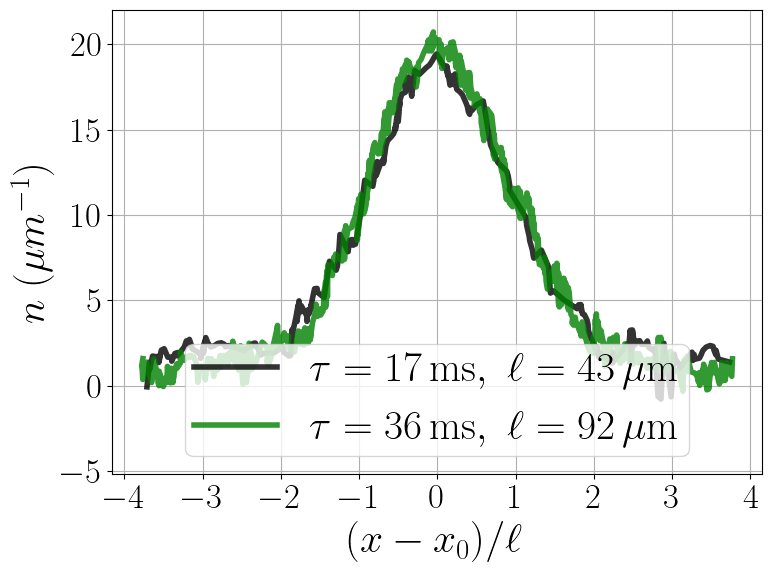

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Activer LaTeX
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 16

# Lecture du CSV
df0 = pd.read_csv("./data/scaling_1_0.csv", sep=";")

print(df.head())

# Convertir les virgules en points
df0["x"] = df0["x"].str.replace(",", ".").astype(float)
df0["y"] = df0["y"].str.replace(",", ".").astype(float)

# ⚠️ Redéfinir x et y après conversion !
x0 = df0["x"]
y0 = df0["y"]

df1 = pd.read_csv("./data/scaling_1_1.csv", sep=";")

print(df1.head())

# Convertir les virgules en points
df1["x"] = df1["x"].str.replace(",", ".").astype(float)
df1["y"] = df1["y"].str.replace(",", ".").astype(float)

# ⚠️ Redéfinir x et y après conversion !
x1 = df1["x"]
y1 = df1["y"]



# Trace
plt.figure(figsize=(8,6))
plt.plot(x0, y0, linewidth=4 , color="black" , alpha = 0.8 , label = r"$\tau = 17\,\mathrm{ms},\ \ell = 43\,\mu\mathrm{m}$" )
plt.plot(x1, y1, linewidth=4 , color="green" , alpha = 0.8 , label = r"$\tau = 36\,\mathrm{ms},\ \ell = 92\,\mu\mathrm{m}$" )

plt.xlabel(r"$(x - x_0)/\ell$", fontsize=30)
plt.ylabel(r"$n\;(\mu m ^{-1})$", fontsize=30)
#plt.title(r"$\tau = 17\,\mathrm{ms},\ \ell = 43\,\mu\mathrm{m}$", fontsize=22)
# Légende centrée en bas du graphe
plt.legend(
    fontsize=30,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),   # décale sous le graphique
    #frameon=False,        # pas de fond ni bordure
    borderpad=0.2,          # padding interne nul
    borderaxespad=1,      # marge avec les axes = 0
    #handlelength=0,       # longueur du trait de légende
    #handletextpad=0       # espace entre trait et texte
)

# Ticks plus gros
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.ylim(-5.2, 22)

plt.grid(True)
plt.tight_layout()
plt.savefig("scaling_1.pdf", dpi=300, bbox_inches="tight")  # PDF pour article
plt.show()


          x         y
0 -3.762544  1.584929
1 -3.777230  1.182331
2 -3.770936  0.934786
3 -3.766740  0.649529
4 -3.763803  0.359949
                    x                      y
0  -9,697566676212297    0,01248831257159222
1  -9,706830016227572   0,010347356457617418
2  -9,690273840206189    0,02060768363402063
3  -9,647383805841928   0,023782941365979388
4  -9,643086817487594    0,02193415306414663


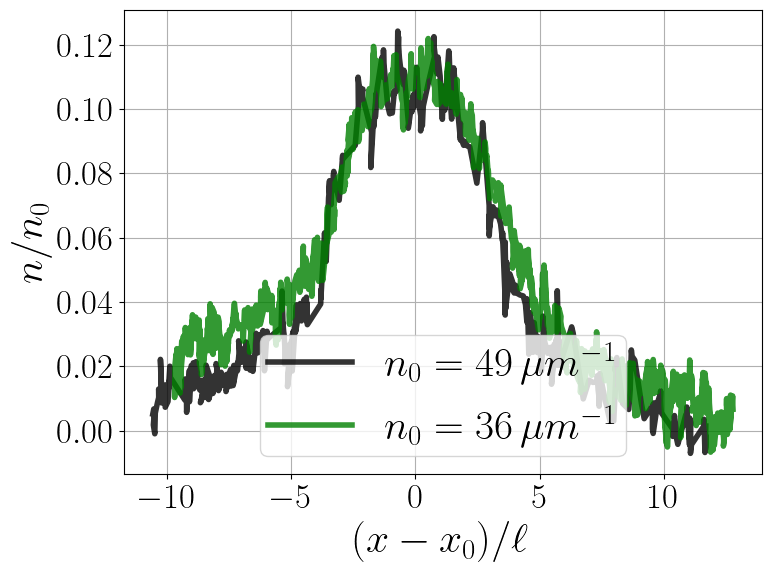

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Activer LaTeX
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 16

# Lecture du CSV
df0 = pd.read_csv("./data/scaling_2_0.csv", sep=";")

print(df.head())

# Convertir les virgules en points
df0["x"] = df0["x"].str.replace(",", ".").astype(float)
df0["y"] = df0["y"].str.replace(",", ".").astype(float)

# ⚠️ Redéfinir x et y après conversion !
x0 = df0["x"]
y0 = df0["y"]

df1 = pd.read_csv("./data/scaling_2_1.csv", sep=";")

print(df1.head())

# Convertir les virgules en points
df1["x"] = df1["x"].str.replace(",", ".").astype(float)
df1["y"] = df1["y"].str.replace(",", ".").astype(float)

# ⚠️ Redéfinir x et y après conversion !
x1 = df1["x"]
y1 = df1["y"]



# Trace
plt.figure(figsize=(8,6))
plt.plot(x0, y0, linewidth=4 , color="black" , alpha = 0.8 , label = r"$n_0 = 49\, \mu m^{-1}$" )
plt.plot(x1, y1, linewidth=4 , color="green" , alpha = 0.8 , label = r"$n_0 = 36\, \mu m^{-1}$" )

plt.xlabel(r"$(x - x_0)/\ell$", fontsize=30)
plt.ylabel(r"$n/n_0$", fontsize=30)
#plt.title(r"$\tau = 17\,\mathrm{ms},\ \ell = 43\,\mu\mathrm{m}$", fontsize=22)
# Légende centrée en bas du graphe
plt.legend(
    fontsize=30,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),   # décale sous le graphique
    #frameon=False,        # pas de fond ni bordure
    borderpad=0.2,          # padding interne nul
    borderaxespad=1,      # marge avec les axes = 0
    #handlelength=0,       # longueur du trait de légende
    #handletextpad=0       # espace entre trait et texte
)

# Ticks plus gros
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

#plt.ylim(-5.2, 22)

plt.grid(True)
plt.tight_layout()
plt.savefig("scaling_2.pdf", dpi=300, bbox_inches="tight")  # PDF pour article
plt.show()
